#NEURAL NETWORKS AND DEEP LEARNING
> M.Sc. ICT FOR LIFE AND HEALTH
> 
> Department of Information Engineering

> M.Sc. COMPUTER ENGINEERING
>
> Department of Information Engineering

> M.Sc. AUTOMATION ENGINEERING
>
> Department of Information Engineering
 
> M.Sc. PHYSICS OF DATA
>
> Department of Physics and Astronomy
 
> M.Sc. COGNITIVE NEUROSCIENCE AND CLINICAL NEUROPSYCHOLOGY
>
> Department of General Psychology

---
A.A. 2020/21 (6 CFU) - Dr. Alberto Testolin, Dr. Matteo Gadaleta
---


## Lab. 05 - Convolutional Autoencoder

An autoencoder, in general, is a network that is trained to attempt to copy its input to its output. Internally, it has a **latent space** that describes a code used to represent the input. The network may be viewed as consisting of two parts: an **encoder** function $h=f(x)$ and a **decoder** that produces a reconstruction $r=g(h)$.

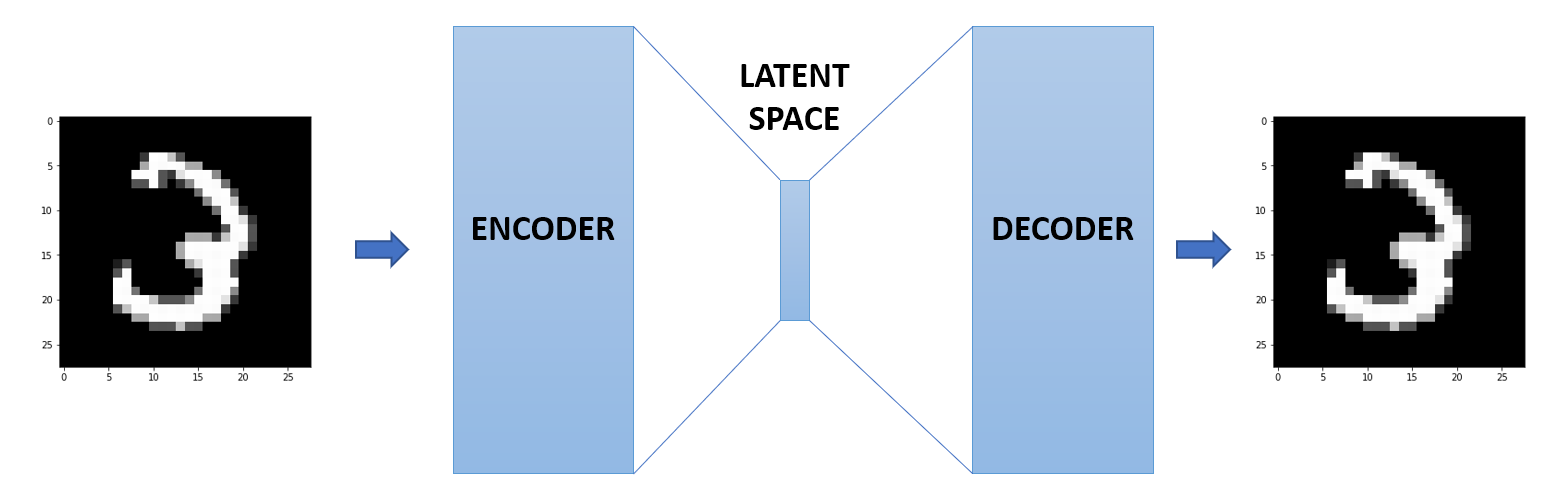

The learning process is described simply as minimizing a loss function $L(x, g(f(x)))$, where $L$ is a loss function penalizing $g(f(x))$ for being dissimilar from $x$, such as the mean squared error.

While the learning is considered to be unsupervised since we are using only the value of $x$, the actual implementation is similar to a supervised setting where the label is just derived from the input.

In [ ]:
import matplotlib.pyplot as plt # plotting library
import numpy as np # this module is useful to work with numerical arrays
import pandas as pd # this module is useful to work with tabular data
import random # this module will be used to select random samples from a collection
import os # this module will be used just to create directories in the local filesystem
from tqdm import tqdm # this module is useful to plot progress bars

import torch
import torchvision
from torchvision import transforms
from torchinfo import summary
from torch.utils.data import DataLoader
from torch import nn


# Dataset

## Define the dataset

For this lab. we will use one of the dataset already included in PyTorch ([https://pytorch.org/docs/stable/torchvision/datasets.html#mnist](https://pytorch.org/docs/stable/torchvision/datasets.html#mnist)). These dataset do not require the definition of a custom `Dataset` class, so we can focus on the network implementation.

The MNIST dataset is a colletion of hand-written digits. The size of the images is $28 \times 28$, and there is a single channel only (black and white images).

In [ ]:
### Download the data and create dataset
data_dir = 'dataset'
# With these commands the train and test datasets, respectively, are downloaded 
# automatically and stored in the local "data_dir" directory.
train_dataset = torchvision.datasets.MNIST(data_dir, train=True, download=True)
test_dataset  = torchvision.datasets.MNIST(data_dir, train=False, download=True)

The output of the dataset is a PIL Image, a standard format for image processing, but we can easily convert the data to a numpy array:
```
image_numpy = np.array(pil_image)
```
or to a PyTorch tensor:
```
to_tensor = torchvision.transforms.ToTensor()
image_tensor = to_tensor(pil_image)
```


Let's plot some random samples from the dataset. The first element of the sample is the actual image, while the second is the corresponding label.

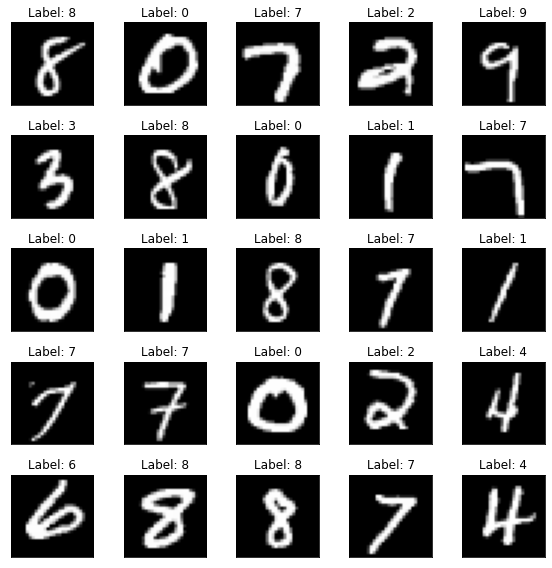

In [ ]:
### Plot some sample
fig, axs = plt.subplots(5, 5, figsize=(8,8))
for ax in axs.flatten():
    # random.choice allows to randomly sample from a list-like object (basically anything that can be accessed with an index, like our dataset)
    img, label = random.choice(train_dataset)
    ax.imshow(np.array(img), cmap='gist_gray')
    ax.set_title('Label: %d' % label)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## Define the dataset transform

In this example we are using the input images without any modification. As always, the only requirement is to transform the input data to tensors of the proper shape.

In [ ]:
# In this case the train_transform and test_transform are the same, but we keep them separate for potential future updates
train_transform = transforms.Compose([
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
])

Since we already defined our datasets, this is an alternative (and recommended) way to add (or modify) a dataset transformation without reinitializing the dataset (very useful when the dataset initialization is slow):

In [ ]:
# Set the train transform
train_dataset.transform = train_transform
# Set the test transform
test_dataset.transform = test_transform

## Define the dataloader

The dataloader allows to easily create batch of data, in this case we set a batch size of 256, and we also enable data shuffling for the training dataset.

In [ ]:
### Define train dataloader
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=False )
### Define test dataloader
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False)


batch_data, batch_labels = next(iter(train_dataloader))
print(f"TRAIN BATCH SHAPE")
print(f"\t Data: {batch_data.shape}")
print(f"\t Labels: {batch_labels.shape}")

batch_data, batch_labels = next(iter(test_dataloader))
print(f"TEST BATCH SHAPE")
print(f"\t Data: {batch_data.shape}")
print(f"\t Labels: {batch_labels.shape}")

TRAIN BATCH SHAPE
	 Data: torch.Size([256, 1, 28, 28])
	 Labels: torch.Size([256])
TEST BATCH SHAPE
	 Data: torch.Size([256, 1, 28, 28])
	 Labels: torch.Size([256])


# Autoencoder

## Encoder

Let's start from the encoder. In the figure you can find a suggested architecture for the encoder, with all the required parameters for each layer.

In this example we are considering a latent space with just **2 variables**, so make sure your encoder generates tensors with the proper shape.

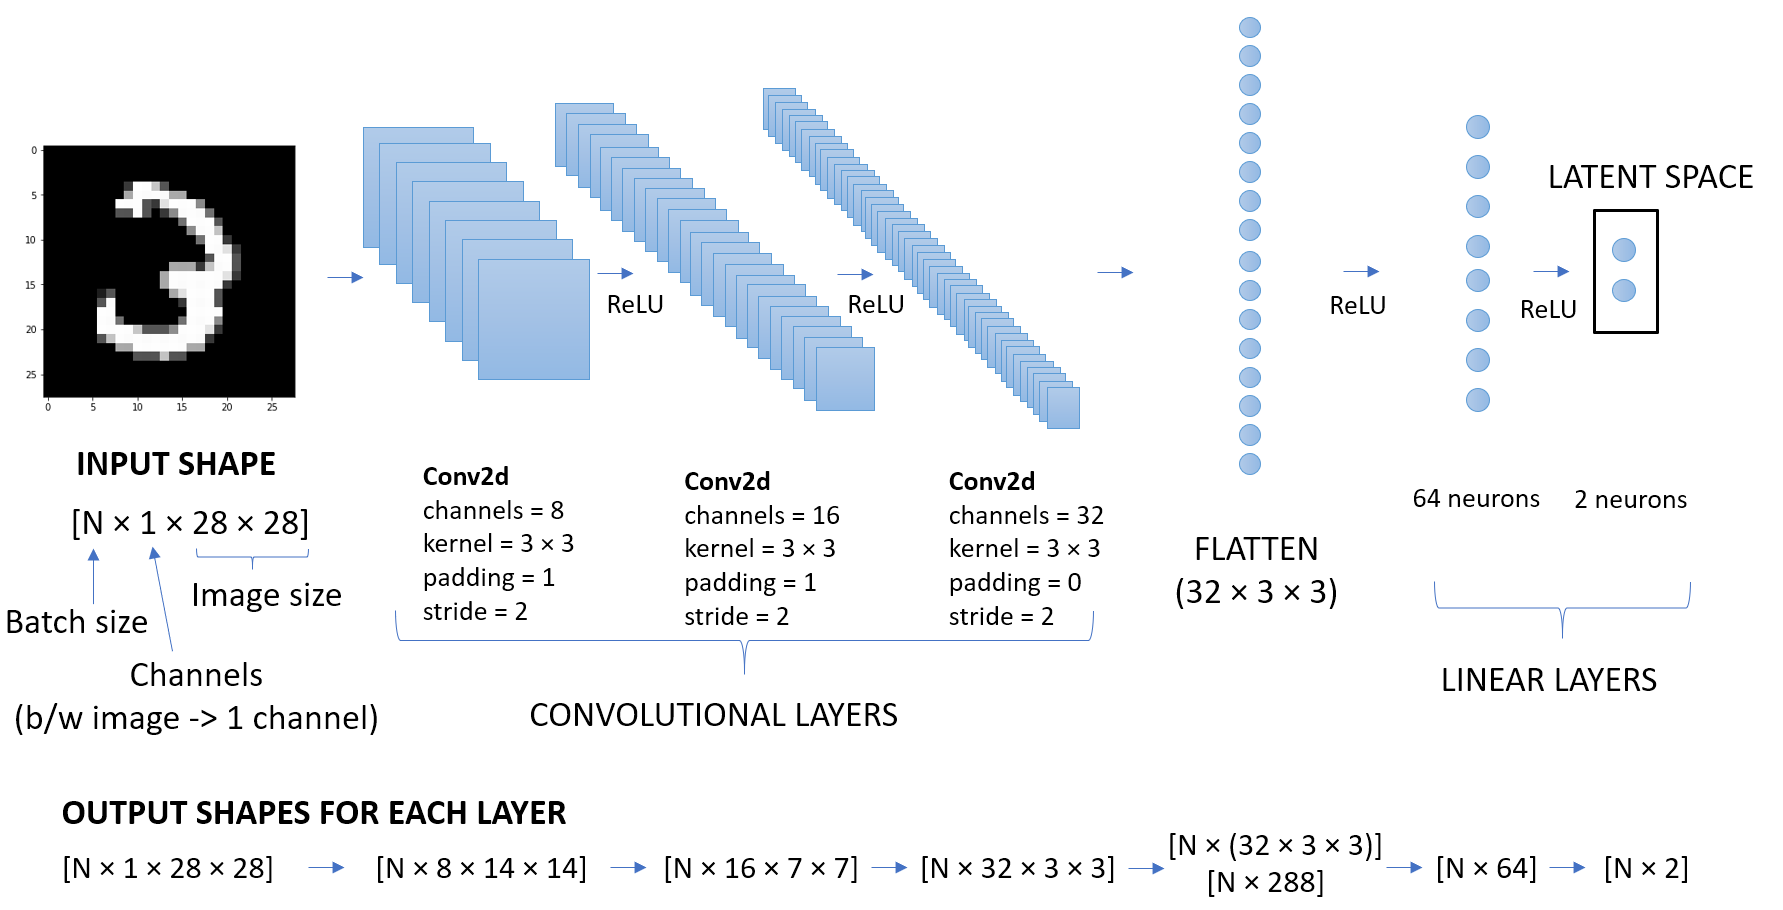

`torch.nn.Sequential` is a utility function that allows to easily concatenate sequential layers, without defining a separate object for each of them (more details here: [torch.nn.Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)).

The output of a convolutional layer is typically multi-dimensional. To apply a linear layer after a convolutional one you should convert your tensor to a monodimensional array. This operation is often referred to as **flattening**. In PyTorch, this can be done with the [`torch.nn.Flatten`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html?highlight=flatten#torch.nn.Flatten)
 layer. By setting `start_dim = 1` we keep the first axis (index 0) as it is (which represents the batch size in our case, that should not be flattened) and all the other axes will be flattened in the new second axis.


In [ ]:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim):
        super().__init__()
        
        ### Convolutional section
        self.encoder_cnn = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            # Second convolutional layer
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.ReLU(True),
            # Third convolutional layer
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        self.flatten = nn.Flatten(start_dim=1)

        ### Linear section
        self.encoder_lin = nn.Sequential(
            # First linear layer
            nn.Linear(3 * 3 * 32, 64),
            nn.ReLU(True),
            # Second linear layer
            nn.Linear(64, encoded_space_dim)
        )

        # ### Mu Sigma Layer
        # self.Mu = nn.Linear(64, encoded_space_dim)
        # self.Sigma = nn.Linear(64, encoded_space_dim)
        
        # self.N = torch.distributions.Normal(0, 1)
        # # self.N.loc = self.N.loc.cuda() # hack to get sampling on the GPU
        # # self.N.scale = self.N.scale.cuda()
        # self.kl = 0
        
    def forward(self, x):
        # Apply convolutions
        x = self.encoder_cnn(x)
        # Flatten
        x = self.flatten(x)
        # Apply linear layers
        x = self.encoder_lin(x)

        # # Get mu and sigma
        # mu = self.Mu(x)
        # sigma = torch.exp(self.Sigma(x))
        # z = mu + sigma*self.N.sample(mu.shape)

        # self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum()
        return x

In [ ]:
class Encoder(nn.Module):
    
    def __init__(self, encoded_space_dim=2):
        super().__init__()
        
        ### Convolutional section
        self.encoder_cnn = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            # Second convolutional layer
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.ReLU(True),
            # Third convolutional layer
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        self.flatten = nn.Flatten(start_dim=1)

        ### Linear section
        self.encoder_lin = nn.Sequential(
            # First linear layer
            nn.Linear(3 * 3 * 32, 64),
            nn.ReLU(True),
            # Second linear layer
            nn.Linear(64, encoded_space_dim)
        )
        
    def forward(self, x):
        # Apply convolutions
        x = self.encoder_cnn(x)
        # Flatten
        x = self.flatten(x)
        # # Apply linear layers
        x = self.encoder_lin(x)
        return x

## Decoder

Typically the structure of the decoder is specular with respect to the encoder, but this is not a strict requirement. Some successfull implementations use very different architectures for the encoder and the decoder. 

The only requirement of the decoder is the input shape, which must match the latent space, and the output shape, that must match the input image. 

In this example we implement a decoder perfectly matched with the encoder architecture, but reversed.

Since the convolutional layers in the encoder perform a down-scaling, we need up-scaling layers in the decoder. To this end we use **transposed convolutions**, already available in PyTorch with the [`torch.nn.ConvTranspose2d`](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html) layer.

Similarly to the `torch.nn.Flatten` layer, the [`torch.nn.Unflatten`](https://pytorch.org/docs/stable/generated/torch.nn.Unflatten.html?highlight=unflatten#torch.nn.Unflatten) layer does the opposite operation. We take the axis at index 1 (`dim=1`) and we reshape it to the proper shape (`unflattened_size=(32, 3, 3)`).

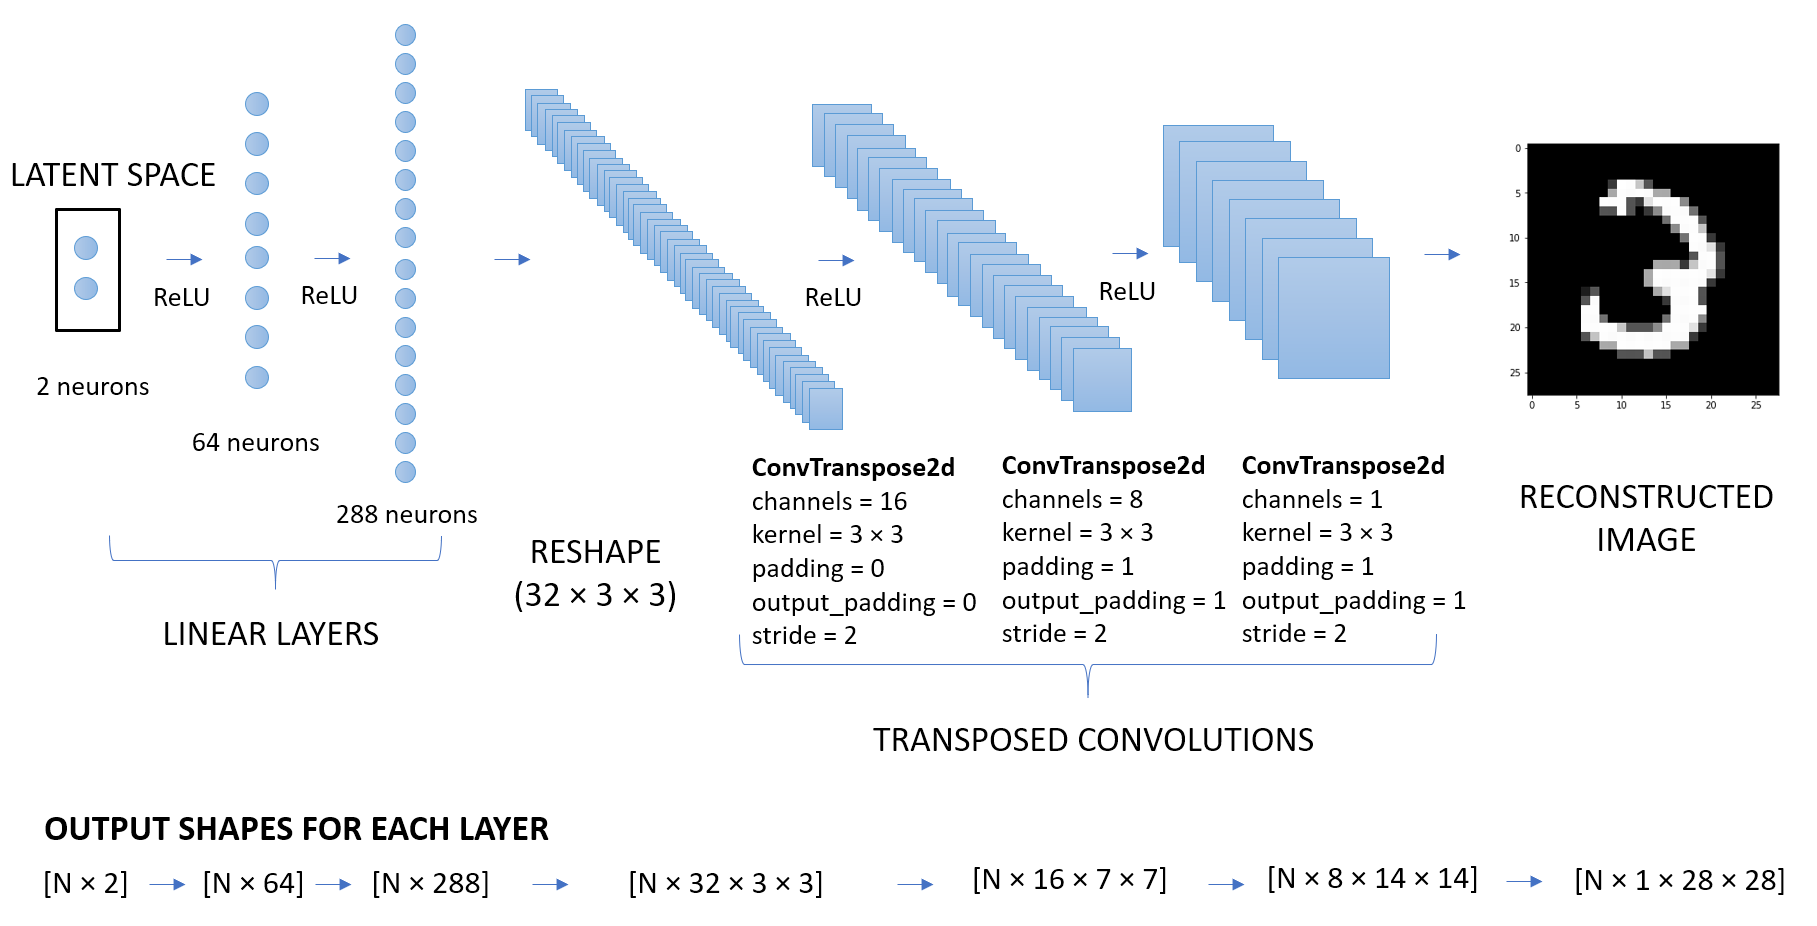

In [ ]:
class Decoder(nn.Module):
    
    def __init__(self, encoded_space_dim=2):
        super().__init__()

        ### Linear section
        self.decoder_lin = nn.Sequential(
            # First linear layer
            nn.Linear(encoded_space_dim, 64),
            nn.ReLU(True),
            # Second linear layer
            nn.Linear(64, 3 * 3 * 32),
            nn.ReLU(True)
        )

        ### Unflatten
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))

        ### Convolutional section
        self.decoder_conv = nn.Sequential(
            # First transposed convolution
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.ReLU(True),
            # Second transposed convolution
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            # Third transposed convolution
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)
        )
        
    def forward(self, x):
        # Apply linear layers
        x = self.decoder_lin(x)
        # Unflatten
        x = self.unflatten(x)
        # Apply transposed convolutions
        x = self.decoder_conv(x)
        # Apply a sigmoid to force the output to be between 0 and 1 (valid pixel values)
        x = torch.sigmoid(x)
        return x

Initialize the two networks.

In [ ]:
### Set the random seed for reproducible results
torch.manual_seed(0)

### Initialize the two networks
encoded_space_dim = 4
encoder = Encoder(encoded_space_dim=encoded_space_dim)
decoder = Decoder(encoded_space_dim=encoded_space_dim)

Let's check if all the shapes are correct.

Original image shape: torch.Size([1, 1, 28, 28])


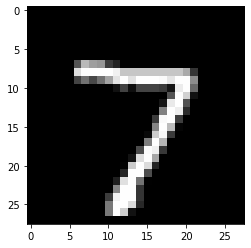

In [ ]:
### Some examples
# Take an input image (remember to add the batch dimension)
img, _ = test_dataset[0]
plt.imshow(img.squeeze(), cmap='gist_gray') # Remove axes of length one from input
img = img.unsqueeze(0) # Add the batch dimension in the first axis
print('Original image shape:', img.shape)

Encoded image shape: torch.Size([1, 4])
Decoded image shape: torch.Size([1, 1, 28, 28])
Decoded and squeezed image shape (28, 28)


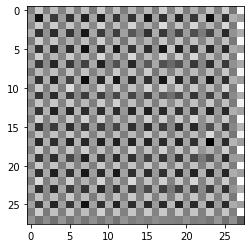

In [ ]:
# Encode the image
img_enc = encoder(img)
print('Encoded image shape:', img_enc.shape)

# Decode the image
dec_img = decoder(img_enc)
plt.imshow(dec_img.detach().squeeze().numpy(), cmap='gist_gray')
print('Decoded image shape:', dec_img.shape)
print('Decoded and squeezed image shape', dec_img.detach().squeeze().numpy().shape)

# Training

The training is similar to the previous examples. The only difference is that now we have 2 different networks. In this situation you have 2 choices:
*   Use a single optimizer to train the parameters of both networks.
*   Define a separate optimizer for each network, and update both of them in the training cycle.

In this case we define a single optimizer for both networks, by just providing a list of the required parameters to the optimizer (see the code below).

You can find more details for all the possible scenarios [here](https://pytorch.org/docs/stable/optim.html).

In [ ]:
### Define the loss function
loss_fn = torch.nn.MSELoss()

### Define an optimizer (both for the encoder and the decoder!)
lr = 1e-3 # Learning rate
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]
optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-5)

# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Selected device: {device}')

# Move both the encoder and the decoder to the selected device
encoder.to(device)
decoder.to(device)

Selected device: cpu


Decoder(
  (decoder_lin): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=288, bias=True)
    (3): ReLU(inplace=True)
  )
  (unflatten): Unflatten(dim=1, unflattened_size=(32, 3, 3))
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(8, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  )
)

## Training function

For a cleaner and more reusable code, we define a training and a testing funcion. This will make the training loop more compact and readable.

The function will train (and test) the network just **for a single epoch**.

In this case, we just track the training loss for each batch. If you want the training loss for the entire epoch, you have to concatenate all the outputs (see the testing function as reference for this case).

In [ ]:
train_dataloader.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: dataset
    Split: Train

In [ ]:
### Training function
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    encoder.train()
    decoder.train()

    batch_losses = []
    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for idx, (image_batch, _) in enumerate(dataloader): # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Move tensor to the proper device
        image_batch = image_batch.to(device)
        # Encode data
        encoded_data = encoder(image_batch)
        # Decode data
        decoded_data = decoder(encoded_data)
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
        batch_losses.append(loss.data)
        if idx % 10 == 0:
          print('\t partial train loss (single batch): %f' % (loss.data))
    return batch_losses

## Testing function

In this case, the testing function has the only goal to evaluate how well we are reproducing the input. We quantify this with the average MSE of the entire test set (which in this case correspond to our loss function, but this is not always true).

Since the entire dataset does not always fit in memory, this example shows how to evaluate the network output in batches, aggregating the results (using `conc_out` and `conc_label` in the code). At the end, you can evaluate a  single overall loss.

In [ ]:
### Testing function
def test_epoch(encoder, decoder, device, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        batch_losses = []
        for image_batch, _ in dataloader:
            # Move tensor to the proper device
            image_batch = image_batch.to(device)
            # Encode data
            encoded_data = encoder(image_batch)
            # Decode data
            decoded_data = decoder(encoded_data)
            loss = loss_fn(decoded_data, image_batch)
            batch_losses.append(loss)
    return batch_losses

## Training loop

Now that we have the training and testing functions, the training loop is considerably simplified. We just need to call these 2 functions for `num_epochs` times.

To see what happen during the training, we also show the output corresponding to a specific image at the end of each epoch.

In [ ]:
### Define the loss function
loss_fn = torch.nn.MSELoss()

### Define an optimizer (both for the encoder and the decoder!)
lr = 1e-3 # Learning rate
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Selected device: {device}')

# Move both the encoder and the decoder to the selected device
encoder.to(device)
decoder.to(device)

epochs = [5, 10, 20, 30]
lrs = [0.001, 0.01]
wds = [1e-6, 1e-5, 1e-4] 
epss = [1e-8, 1e-7] 

epoch_num = 2

Selected device: cpu


In [ ]:
train_loss_log = []
val_loss_log = []

metas = []

for lr in lrs:
  for wd in wds:
    optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=wd)
    optim.zero_grad()
    print(f'\n PARAMS:\n\tLearning rate: {lr}\n\tWeight decay: {wd}\n')
    for epoch in range(epoch_num):
      print('EPOCH %d/%d' % (epoch + 1, epoch_num))
      ### Training (use the training function)
      train_loss_arr = train_epoch(
          encoder=encoder, 
          decoder=decoder, 
          device=device, 
          dataloader=train_dataloader, 
          loss_fn=loss_fn, 
          optimizer=optim)
      train_loss = np.mean(train_loss_arr)
      train_loss_log.append(train_loss)
      
      # Print training epoch number
      print('\n\t TRAIN - EPOCH %d/%d - loss: %f\n\n' % (epoch + 1, epoch_num, train_loss))
      
      ### Validation  (use the testing function)
      val_loss_arr = test_epoch(
          encoder=encoder, 
          decoder=decoder, 
          device=device, 
          dataloader=test_dataloader, 
          loss_fn=loss_fn)
      val_loss = np.mean(val_loss_arr)
      val_loss_log.append(val_loss)
      # Print and store Validation loss
      print('\n\n\t VALIDATION - EPOCH %d/%d - loss: %f\n\n' % (epoch + 1, epoch_num, val_loss))

      ### Plot progress
      # Get the output of a specific image (the test image at index 0 in this case)
      img = test_dataset[0][0].unsqueeze(0).to(device)
      encoder.eval()
      decoder.eval()
      with torch.no_grad():
          rec_img  = decoder(encoder(img))
      # Plot the reconstructed image
      fig, axs = plt.subplots(1, 2, figsize=(12,6))
      axs[0].imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
      axs[0].set_title('Original image')
      axs[1].imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
      axs[1].set_title('Reconstructed image (EPOCH %d)' % (epoch + 1))
      plt.tight_layout()
      plt.pause(0.1)
      # Save figures
      os.makedirs('autoencoder_progress_%d_features' % encoded_space_dim, exist_ok=True)
      fig.savefig('autoencoder_progress_%d_features/epoch_%d.jpg' % (encoded_space_dim, epoch + 1))
      plt.show()
      plt.close()

      # Save network parameters
      torch.save(encoder.state_dict(), 'encoder_params.pth')
      torch.save(decoder.state_dict(), 'decoder_params.pth')

    meta = {
      'optim':{
        'name':'Adam',
        'lr':lr,
        'wd':wd
        },
      'losses':{
          'train_loss':train_loss_log,
          'val_loss':val_loss_log
      }}
    metas.append(meta)
    train_loss_log = []
    val_loss_log = []

In [ ]:
metas

[{'losses': {'train_loss': [0.09923622, 0.05599734],
   'val_loss': [0.064586714, 0.048995335]},
  'optim': {'lr': 0.001, 'name': 'Adam', 'wd': 1e-06}},
 {'losses': {'train_loss': [0.04510115, 0.03982793],
   'val_loss': [0.041893147, 0.0377417]},
  'optim': {'lr': 0.001, 'name': 'Adam', 'wd': 1e-05}}]

## Plot train and validation losses

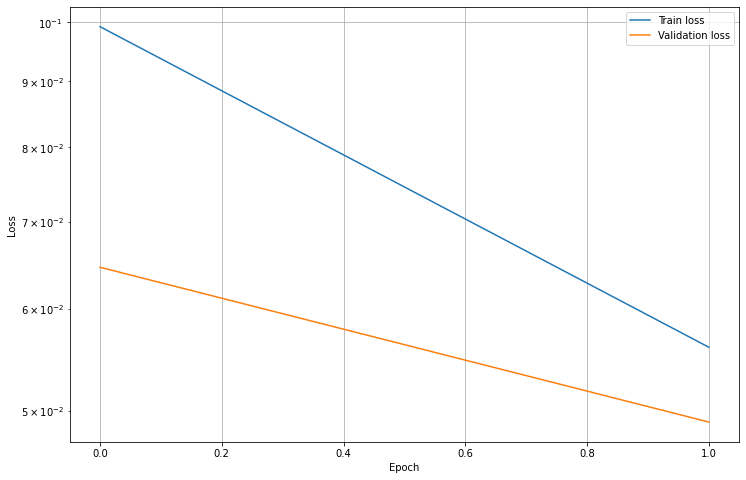

In [ ]:
# Plot losses
plt.figure(figsize=(12,8))
plt.semilogy(metas[0]['losses']['train_loss'], label='Train loss')
plt.semilogy(metas[0]['losses']['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

IndexError: ignored

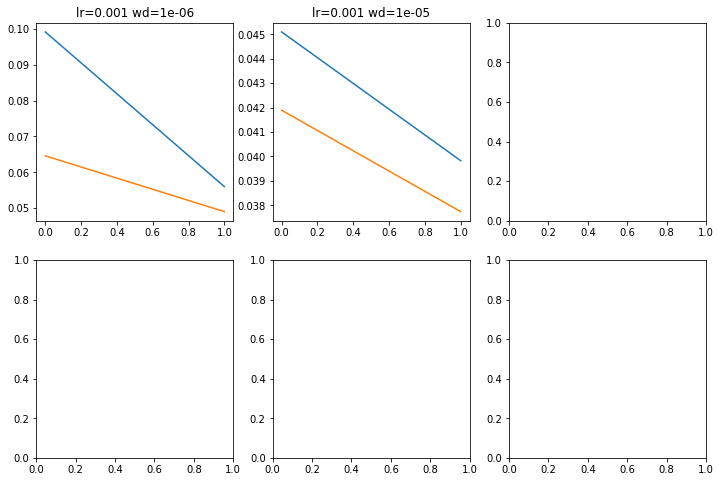

In [ ]:
### Plot some sample
fig, axs = plt.subplots(len(lrs), len(wds), figsize=(12,8))
for idx, ax in enumerate(axs.flatten()):
  ax.set_title(f"lr={metas[idx]['optim']['lr']} wd={metas[idx]['optim']['wd']}")
  ax.plot(metas[idx]['losses']['train_loss'])
  ax.plot(metas[idx]['losses']['val_loss'])
plt.tight_layout()

# Network Analysis

If you have a previously saved network, restore the network parameters.

In [ ]:
# Load network parameters
encoder.load_state_dict(torch.load('encoder_params.pth'))
decoder.load_state_dict(torch.load('decoder_params.pth'))

<All keys matched successfully>

The encoder can be used to evaluate the latent space values for each of the test images. Since we used an encoded space dimension of 2, the encoder maps an entire image to just 2 floating point numbers.

We also save the corresponding label to show how each digit is mapped in the encoded space.

In [ ]:
### Get the encoded representation of the test samples
encoded_samples = []
for sample in tqdm(test_dataset):
    img = sample[0].unsqueeze(0).to(device)
    label = sample[1]
    # Encode image
    encoder.eval()
    with torch.no_grad():
        encoded_img  = encoder(img)
    # Append to list
    encoded_img = encoded_img.flatten().cpu().numpy()
    encoded_sample = {f"Enc. Variable {i}": enc for i, enc in enumerate(encoded_img)}
    encoded_sample['label'] = label
    encoded_samples.append(encoded_sample)

100%|██████████| 10000/10000 [00:05<00:00, 1925.21it/s]


For convenience (not required), convert the result to a table format (`pandas.DataFrame`):

In [ ]:
# Convert to a dataframe
encoded_samples = pd.DataFrame(encoded_samples)
encoded_samples

,Enc. Variable 0,Enc. Variable 1,Enc. Variable 2,Enc. Variable 3,label
0,-77.897980,20.686546,26.781086,-5.616775,7
1,38.071930,39.401390,-20.037001,-50.957211,2
2,-69.216637,56.024841,-51.894337,-87.064194,1
3,20.579308,17.378109,-33.399750,2.336431,0
4,-11.382145,64.284859,-5.432821,29.179564,4
...,...,...,...,...,...
9995,6.809929,-0.730580,-0.215142,-38.970928,2
9996,32.431702,20.063496,-19.544241,-27.392879,3
9997,-29.768198,23.127594,-14.865501,4.900210,4
9998,-17.289600,9.287227,-40.573078,-1.371415,5


This graph shows where each input image is mapped in the encoded space. Since we have just 2 encoded variables, we can easily plot them in a bidimensional space. 

In [ ]:
from sklearn.manifold import TSNE

labels = encoded_samples.iloc[:, -1]
reduced_encoded_samples = encoded_samples.iloc[:, :-1]

if encoded_space_dim > 2:
  reduced_encoded_samples = TSNE(n_components=2, init='pca').fit_transform(reduced_encoded_samples)
  reduced_encoded_samples = pd.DataFrame(reduced_encoded_samples)
  reduced_encoded_samples

KeyboardInterrupt: ignored

In [ ]:
reduced_encoded_samples.iloc[:, 0]

In [ ]:
import plotly.express as px
px.scatter(reduced_encoded_samples, x = reduced_encoded_samples.iloc[:, 0], y = reduced_encoded_samples.iloc[:, 1], color=labels.astype(str), opacity=0.7)

As you can see from the graph, even if we never used the labels (i.e. the actual digit written in the image) during the training, the network has been able to clusterize quite well the different classes.

> **NOTE**
> 
> The encoded space may have many more variables. In this case you can still have a visual representation of the encoded space by applying a dimensionality reduction method, such as:
- [Princiapal Component Analysis (PCA)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [t-distributed Stochastic Neighbor Embedding (t-SNE)](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)




While the encoder is able to map the image to the encoded space, the decoder can do the opposite, generating an image given the corresponding latent space values.

The latent space can also be manually customized, like in the following example, where we generate images with the decoder by providing custom latent space variables.

In [ ]:
# Generate a custom sample
custom_encoded_sample = [20, 5, 10, 15]
encoded_value = torch.tensor(custom_encoded_sample).float().unsqueeze(0).to(device)

# Decode sample
decoder.eval()
with torch.no_grad():
    generated_img  = decoder(encoded_value)
    
plt.figure(figsize=(12,10))
plt.imshow(generated_img.squeeze().cpu().numpy(), cmap='gist_gray')
plt.show()

# Interpolate

In [ ]:
def interpolate(encoder, decoder, x_1, x_2, n=12):
    z_1 = encoder(x_1)
    z_2 = encoder(x_2)
    z = torch.stack([z_1 + (z_2 - z_1)*t for t in np.linspace(0, 1, n)])
    z = z.squeeze(1)
    
    interpolate_list = decoder(z)
    interpolate_list = interpolate_list.to('cpu').detach().numpy()

    w = 28
    img = np.zeros((w, n*w))
    for i, x_hat in enumerate(interpolate_list):
        img[:, i*w:(i+1)*w] = x_hat.reshape(28, 28)
    plt.imshow(img, cmap='gist_gray')
    plt.xticks([])
    plt.yticks([])

In [ ]:
x, y = train_dataloader.__iter__().next() # hack to grab a batch
x_1 = x[y == 0][0].unsqueeze(0) # find a 1
x_2 = x[y == 9][0].unsqueeze(0) # find a 0

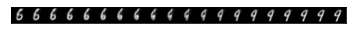

In [ ]:
interpolate(encoder, decoder, x_1, x_2, 20)

# Denoising Autoencoder

In [ ]:
def add_noise(inputs):
     noise = torch.randn_like(inputs)*0.2
     return inputs + noise

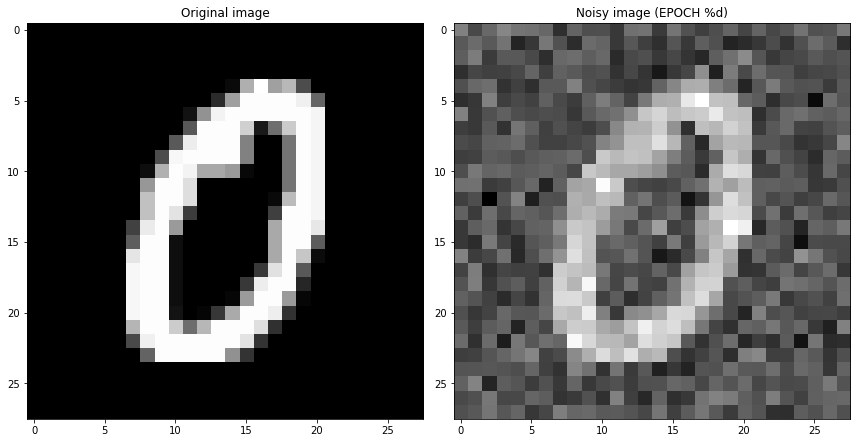

In [ ]:
images = next(iter(train_dataloader))
images = images[0]
noisy_images = add_noise(images)

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(images[0].cpu().squeeze().numpy(), cmap='gist_gray')
axs[0].set_title('Original image')
axs[1].imshow(noisy_images[0].cpu().squeeze().numpy(), cmap='gist_gray')
axs[1].set_title('Noisy image (EPOCH %d)')
plt.tight_layout()

In [ ]:
### Training function
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer):
    # Set train mode for both the encoder and the decoder
    encoder.train()
    decoder.train()

    # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
    for idx, (image_batch, _) in enumerate(dataloader): # with "_" we just ignore the labels (the second element of the dataloader tuple)
        # Move tensor to the proper device
        image_batch = image_batch.to(device)
        noisy_image_batch = add_noise(image_batch)
        # Encode data
        encoded_data = encoder(noisy_image_batch)
        # Decode data
        decoded_data = decoder(encoded_data)
        # Evaluate loss
        loss = loss_fn(decoded_data, image_batch)
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Print batch loss
        if idx % 10 == 0:
          print('\t partial train loss (single batch): %f' % (loss.data))

In [ ]:
### Testing function
def test_epoch(encoder, decoder, device, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_out = []
        conc_label = []
        for image_batch, _ in dataloader:
            # Move tensor to the proper device
            image_batch = image_batch.to(device)
            noisy_image_batch = add_noise(image_batch)
            # Encode data
            encoded_data = encoder(noisy_image_batch)
            # Decode data
            decoded_data = decoder(encoded_data)
            # Append the network output and the original image to the lists
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
        # Create a single tensor with all the values in the lists
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label) 
        # Evaluate global loss
        val_loss = loss_fn(conc_out, conc_label)
    return val_loss.data

EPOCH 1/40
	 partial train loss (single batch): 0.029686
	 partial train loss (single batch): 0.029909
	 partial train loss (single batch): 0.030409
	 partial train loss (single batch): 0.029543
	 partial train loss (single batch): 0.031160
	 partial train loss (single batch): 0.028789
	 partial train loss (single batch): 0.030219
	 partial train loss (single batch): 0.031300
	 partial train loss (single batch): 0.029674
	 partial train loss (single batch): 0.029155
	 partial train loss (single batch): 0.031200
	 partial train loss (single batch): 0.030180
	 partial train loss (single batch): 0.029516
	 partial train loss (single batch): 0.031665
	 partial train loss (single batch): 0.029127
	 partial train loss (single batch): 0.030586
	 partial train loss (single batch): 0.030830
	 partial train loss (single batch): 0.031436
	 partial train loss (single batch): 0.028880
	 partial train loss (single batch): 0.030115
	 partial train loss (single batch): 0.031865
	 partial train loss (s

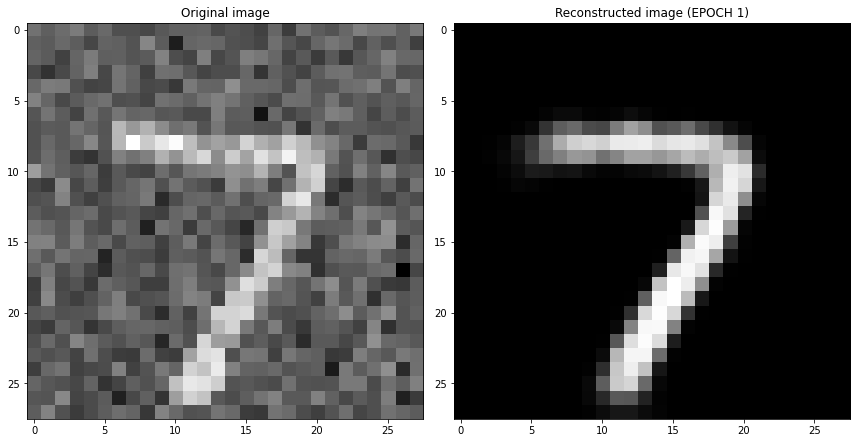

EPOCH 2/40
	 partial train loss (single batch): 0.030128
	 partial train loss (single batch): 0.031456
	 partial train loss (single batch): 0.028370
	 partial train loss (single batch): 0.030151
	 partial train loss (single batch): 0.027648
	 partial train loss (single batch): 0.031706
	 partial train loss (single batch): 0.029987
	 partial train loss (single batch): 0.031814
	 partial train loss (single batch): 0.028517
	 partial train loss (single batch): 0.031708
	 partial train loss (single batch): 0.029789
	 partial train loss (single batch): 0.029384
	 partial train loss (single batch): 0.029483
	 partial train loss (single batch): 0.030735
	 partial train loss (single batch): 0.029956
	 partial train loss (single batch): 0.029322
	 partial train loss (single batch): 0.029058
	 partial train loss (single batch): 0.029127
	 partial train loss (single batch): 0.029239
	 partial train loss (single batch): 0.028270
	 partial train loss (single batch): 0.031320
	 partial train loss (s

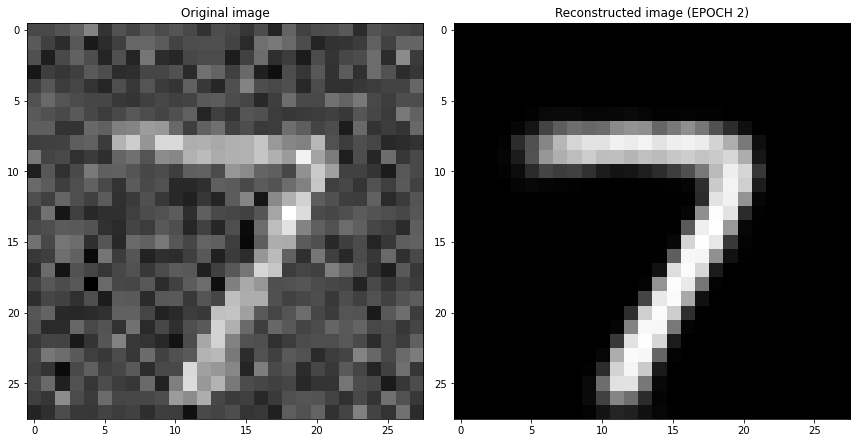

EPOCH 3/40
	 partial train loss (single batch): 0.031112
	 partial train loss (single batch): 0.029794
	 partial train loss (single batch): 0.029326
	 partial train loss (single batch): 0.030061
	 partial train loss (single batch): 0.029458
	 partial train loss (single batch): 0.029606
	 partial train loss (single batch): 0.027221
	 partial train loss (single batch): 0.031365
	 partial train loss (single batch): 0.029122
	 partial train loss (single batch): 0.030820
	 partial train loss (single batch): 0.030928
	 partial train loss (single batch): 0.027938
	 partial train loss (single batch): 0.029947
	 partial train loss (single batch): 0.030144
	 partial train loss (single batch): 0.028730
	 partial train loss (single batch): 0.028800
	 partial train loss (single batch): 0.029552
	 partial train loss (single batch): 0.028152
	 partial train loss (single batch): 0.028168
	 partial train loss (single batch): 0.029371
	 partial train loss (single batch): 0.028587
	 partial train loss (s

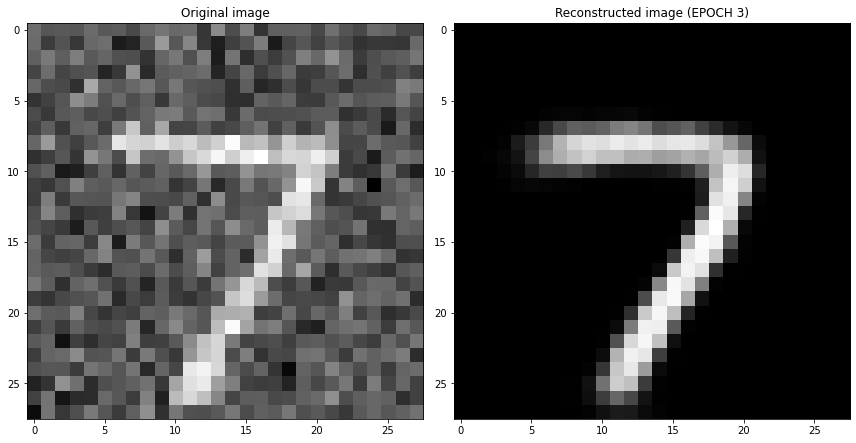

EPOCH 4/40
	 partial train loss (single batch): 0.028754
	 partial train loss (single batch): 0.029736
	 partial train loss (single batch): 0.029397
	 partial train loss (single batch): 0.029591
	 partial train loss (single batch): 0.027835
	 partial train loss (single batch): 0.029832
	 partial train loss (single batch): 0.031533
	 partial train loss (single batch): 0.029962
	 partial train loss (single batch): 0.030106
	 partial train loss (single batch): 0.029721
	 partial train loss (single batch): 0.029901
	 partial train loss (single batch): 0.029409
	 partial train loss (single batch): 0.031086
	 partial train loss (single batch): 0.029037
	 partial train loss (single batch): 0.029803
	 partial train loss (single batch): 0.029075
	 partial train loss (single batch): 0.030069
	 partial train loss (single batch): 0.029220
	 partial train loss (single batch): 0.028372
	 partial train loss (single batch): 0.028652
	 partial train loss (single batch): 0.029064
	 partial train loss (s

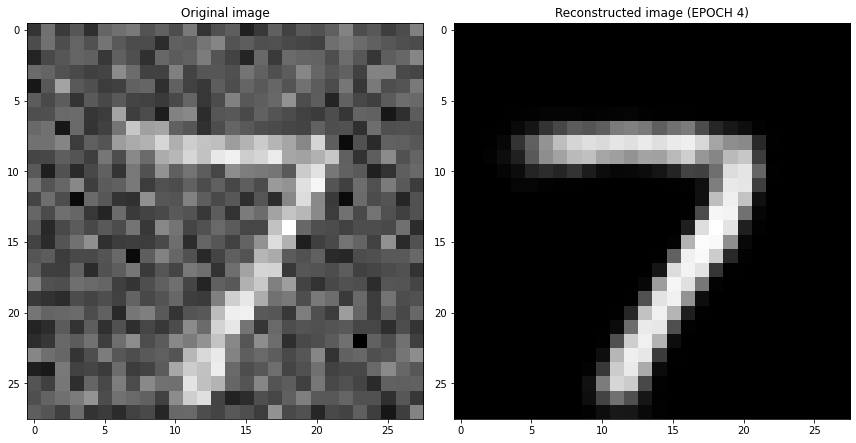

EPOCH 5/40
	 partial train loss (single batch): 0.029114
	 partial train loss (single batch): 0.028522
	 partial train loss (single batch): 0.030342
	 partial train loss (single batch): 0.029478
	 partial train loss (single batch): 0.029260
	 partial train loss (single batch): 0.029180
	 partial train loss (single batch): 0.029379
	 partial train loss (single batch): 0.028792
	 partial train loss (single batch): 0.029487
	 partial train loss (single batch): 0.028693
	 partial train loss (single batch): 0.030532
	 partial train loss (single batch): 0.029622
	 partial train loss (single batch): 0.029310
	 partial train loss (single batch): 0.030747
	 partial train loss (single batch): 0.029630
	 partial train loss (single batch): 0.029276
	 partial train loss (single batch): 0.029239
	 partial train loss (single batch): 0.029980
	 partial train loss (single batch): 0.029422
	 partial train loss (single batch): 0.028889
	 partial train loss (single batch): 0.029791
	 partial train loss (s

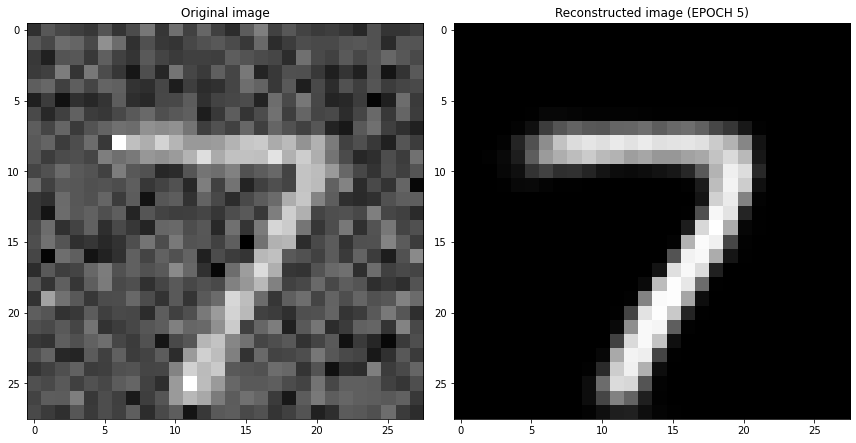

EPOCH 6/40
	 partial train loss (single batch): 0.030133
	 partial train loss (single batch): 0.029456
	 partial train loss (single batch): 0.029481
	 partial train loss (single batch): 0.030208
	 partial train loss (single batch): 0.028753
	 partial train loss (single batch): 0.031847
	 partial train loss (single batch): 0.030169
	 partial train loss (single batch): 0.031305
	 partial train loss (single batch): 0.028866
	 partial train loss (single batch): 0.028750
	 partial train loss (single batch): 0.030719
	 partial train loss (single batch): 0.028913
	 partial train loss (single batch): 0.029978
	 partial train loss (single batch): 0.028089
	 partial train loss (single batch): 0.029471
	 partial train loss (single batch): 0.029498
	 partial train loss (single batch): 0.027806
	 partial train loss (single batch): 0.027498
	 partial train loss (single batch): 0.027913
	 partial train loss (single batch): 0.027320
	 partial train loss (single batch): 0.030045
	 partial train loss (s

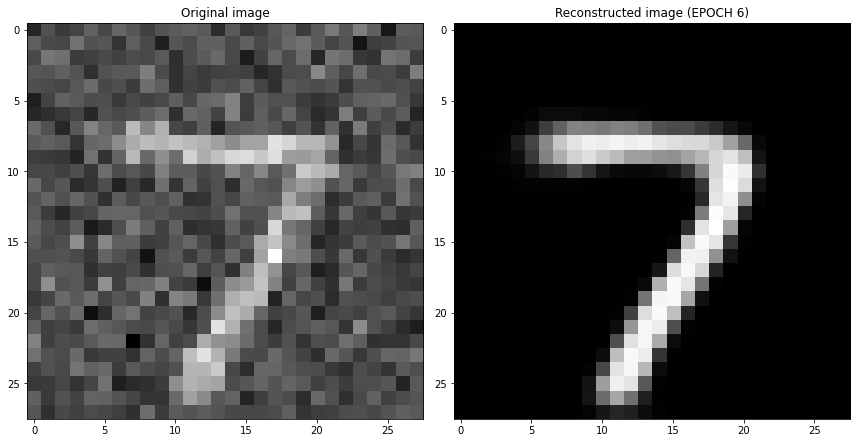

EPOCH 7/40
	 partial train loss (single batch): 0.030029
	 partial train loss (single batch): 0.030061
	 partial train loss (single batch): 0.028599
	 partial train loss (single batch): 0.029415
	 partial train loss (single batch): 0.028684
	 partial train loss (single batch): 0.029937
	 partial train loss (single batch): 0.027984
	 partial train loss (single batch): 0.028851
	 partial train loss (single batch): 0.029054
	 partial train loss (single batch): 0.028582
	 partial train loss (single batch): 0.028481
	 partial train loss (single batch): 0.030647
	 partial train loss (single batch): 0.029004
	 partial train loss (single batch): 0.030949
	 partial train loss (single batch): 0.031461
	 partial train loss (single batch): 0.030354
	 partial train loss (single batch): 0.029313
	 partial train loss (single batch): 0.029324
	 partial train loss (single batch): 0.029684
	 partial train loss (single batch): 0.029205
	 partial train loss (single batch): 0.030408
	 partial train loss (s

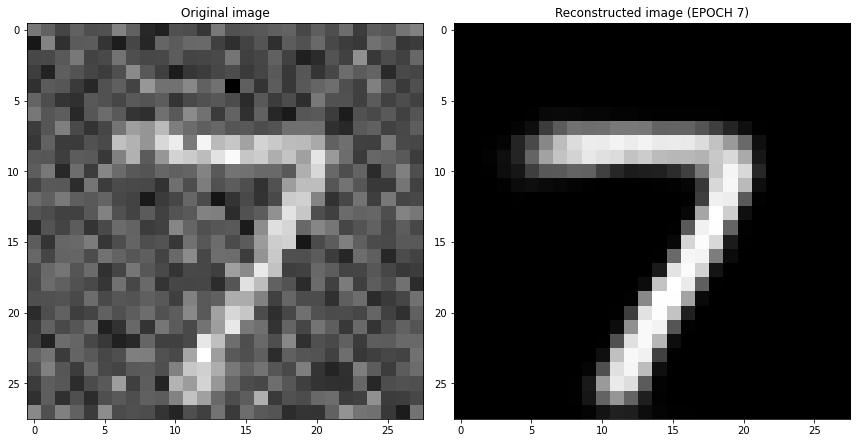

EPOCH 8/40
	 partial train loss (single batch): 0.028492
	 partial train loss (single batch): 0.028304
	 partial train loss (single batch): 0.028406
	 partial train loss (single batch): 0.029074
	 partial train loss (single batch): 0.028841
	 partial train loss (single batch): 0.029757
	 partial train loss (single batch): 0.029543
	 partial train loss (single batch): 0.027869
	 partial train loss (single batch): 0.027695
	 partial train loss (single batch): 0.030739
	 partial train loss (single batch): 0.028492
	 partial train loss (single batch): 0.029031
	 partial train loss (single batch): 0.029543
	 partial train loss (single batch): 0.029254
	 partial train loss (single batch): 0.029341


KeyboardInterrupt: ignored

In [ ]:
### Training cycle
num_epochs = 10
for epoch in range(num_epochs):
    print('EPOCH %d/%d' % (epoch + 1, num_epochs))
    ### Training (use the training function)
    train_epoch(
        encoder=encoder, 
        decoder=decoder, 
        device=device, 
        dataloader=train_dataloader, 
        loss_fn=loss_fn, 
        optimizer=optim)
    ### Validation  (use the testing function)
    val_loss = test_epoch(
        encoder=encoder, 
        decoder=decoder, 
        device=device, 
        dataloader=test_dataloader, 
        loss_fn=loss_fn)
    # Print Validationloss
    print('\n\n\t VALIDATION - EPOCH %d/%d - loss: %f\n\n' % (epoch + 1, num_epochs, val_loss))

    ### Plot progress
    # Get the output of a specific image (the test image at index 0 in this case)
    img = test_dataset[0][0].unsqueeze(0).to(device)
    noisy_img = add_noise(img)
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        rec_img  = decoder(encoder(noisy_img))
    # Plot the reconstructed image
    fig, axs = plt.subplots(1, 2, figsize=(12,6))
    axs[0].imshow(noisy_img.cpu().squeeze().numpy(), cmap='gist_gray')
    axs[0].set_title('Original image')
    axs[1].imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
    axs[1].set_title('Reconstructed image (EPOCH %d)' % (epoch + 1))
    plt.tight_layout()
    plt.pause(0.1)
    # Save figures
    os.makedirs('autoencoder_progress_%d_features' % encoded_space_dim, exist_ok=True)
    fig.savefig('autoencoder_progress_%d_features/epoch_%d.jpg' % (encoded_space_dim, epoch + 1))
    plt.show()
    plt.close()

    # Save network parameters
    torch.save(encoder.state_dict(), 'encoder_params.pth')
    torch.save(decoder.state_dict(), 'decoder_params.pth')

    # NOTE: Remember to save also the parameters of the optimizer if you want to restore and continue the training

# Supervised Classification Task

## Transform

In [ ]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5))])

##Dataset and Dataloader

In [ ]:
train_dataset = torchvision.datasets.MNIST(root='classifier_data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.MNIST(root='classifier_data', train=False,
                                       download=True, transform=transform)

In [ ]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=128,
                                          shuffle=True, num_workers=2)

test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=128,
                                         shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

SAMPLE AT INDEX 10
LABEL: 3



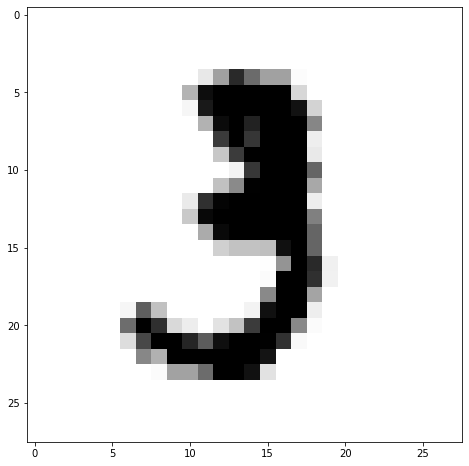

In [ ]:
sample_index = 10
image = train_dataset[sample_index][0]
label = train_dataset[sample_index][1]

fig = plt.figure(figsize=(8,8))
plt.imshow(image.squeeze(), cmap='Greys')
print(f"SAMPLE AT INDEX {sample_index}")
print(f"LABEL: {label}\n")

## Network

In [ ]:
class CEncoder(nn.Module):
    
    def __init__(self, encoded_space_dim=2):
        super().__init__()
        
        ### Convolutional section
        self.encoder_cnn = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            # Second convolutional layer
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.ReLU(True),
            # Third convolutional layer
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )
        
        ### Flatten layer
        self.flatten = nn.Flatten(start_dim=1)

        ### Linear section
        self.encoder_lin = nn.Sequential(
            # First linear layer
            nn.Linear(3 * 3 * 32, 64),
            nn.ReLU(True),
            # Second linear layer
            nn.Linear(64, encoded_space_dim)
        )
        
    def forward(self, x):
        # Apply convolutions
        x = self.encoder_cnn(x)
        # Flatten
        x = self.flatten(x)
        # # Apply linear layers
        x = self.encoder_lin(x)
        return x

In [ ]:
class CDecoder(nn.Module):
    
    def __init__(self, encoded_space_dim=2):
        super().__init__()

        ### Linear section
        self.decoder_lin = nn.Sequential(
            # First linear layer
            nn.Linear(encoded_space_dim, 64),
            nn.ReLU(True),
            # Second linear layer
            nn.Linear(64, 3 * 3 * 32),
            nn.ReLU(True)
        )

        ### Unflatten
        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))

        ### Convolutional section
        self.decoder_conv = nn.Sequential(
            # First transposed convolution
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.ReLU(True),
            # Second transposed convolution
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(True),
            # Third transposed convolution
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1),
            )
        
        ### Linear block
        self.linear_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        # Apply linear layers
        x = self.decoder_lin(x)
        # Unflatten
        x = self.unflatten(x)
        # Apply transposed convolutions
        x = self.decoder_conv(x)
        x = self.linear_block(x)
        # Apply a sigmoid to force the output to be between 0 and 1 (valid pixel values)
        x = torch.sigmoid(x)
        x = torch.log_softmax(x, dim=1)
        return x

In [ ]:
cdecoder = CDecoder()
summary(cdecoder, (128, 2))

Layer (type:depth-idx)                   Output Shape              Param #
CDecoder                                 --                        --
├─Sequential: 1-1                        [128, 288]                --
│    └─Linear: 2-1                       [128, 64]                 192
│    └─ReLU: 2-2                         [128, 64]                 --
│    └─Linear: 2-3                       [128, 288]                18,720
│    └─ReLU: 2-4                         [128, 288]                --
├─Unflatten: 1-2                         [128, 32, 3, 3]           --
├─Sequential: 1-3                        [128, 1, 28, 28]          --
│    └─ConvTranspose2d: 2-5              [128, 16, 7, 7]           4,624
│    └─ReLU: 2-6                         [128, 16, 7, 7]           --
│    └─ConvTranspose2d: 2-7              [128, 8, 14, 14]          1,160
│    └─ReLU: 2-8                         [128, 8, 14, 14]          --
│    └─ConvTranspose2d: 2-9              [128, 1, 28, 28]          73
├─Se

In [ ]:
### Set the random seed for reproducible results
torch.manual_seed(0)

### Initialize the two networks
encoded_space_dim = 2
cencoder = CEncoder(encoded_space_dim=encoded_space_dim)
cdecoder = CDecoder(encoded_space_dim=encoded_space_dim)

In [ ]:
# cencoded_value = torch.tensor([1,1]).float().unsqueeze(0)
# cdecoder.forward(cencoded_value)

In [ ]:
### Define the loss function
loss_fn = torch.nn.CrossEntropyLoss()

### Define an optimizer (both for the encoder and the decoder!)
lr = 0.003 # Learning rate
params_to_optimize = [
    {'params': cencoder.parameters()},
    {'params': cdecoder.parameters()}
]

optim = torch.optim.Adam(params_to_optimize, lr=lr)


# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Selected device: {device}')

# Move both the encoder and the decoder to the selected device
cencoder.to(device)
cdecoder.to(device)

epoch_num = 2

Selected device: cpu


In [ ]:
### Training function
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer):
  # Set train mode for both the encoder and the decoder
  encoder.train()
  decoder.train()
  # Iterate the dataloader (we do not need the label values, this is unsupervised learning)
  for data in dataloader: # with "_" we just ignore the labels (the second element of the dataloader tuple)
      image_batch, labels = data
      # Move tensor to the proper device
      image_batch = image_batch.to(device)
      # Encode data
      encoded_data = encoder(image_batch)
      # Decode data
      decoded_data = decoder(encoded_data)
      # Evaluate loss
      loss = loss_fn(decoded_data, labels)
      # Backward pass
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      # Print batch loss
      print('\t partial train loss (single batch): %f' % (loss.data))

In [ ]:
### Testing function
def test_epoch(encoder, decoder, device, dataloader, loss_fn):
    # Set evaluation mode for encoder and decoder
    encoder.eval()
    decoder.eval()

    correct = 0
    total = 0
    with torch.no_grad():
        for data in dataloader:
            images, labels = data
            outputs = cdecoder(cencoder(images))
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct, total

In [ ]:
### Training cycle
num_epochs = 20
for epoch in range(num_epochs):
    print('EPOCH %d/%d' % (epoch + 1, num_epochs))
    ### Training (use the training function)
    train_epoch(
        encoder=cencoder, 
        decoder=cdecoder, 
        device=device, 
        dataloader=train_dataloader, 
        loss_fn=loss_fn, 
        optimizer=optim)
    ### Validation  (use the testing function)
    correct, total = test_epoch(
        encoder=cencoder, 
        decoder=cdecoder, 
        device=device, 
        dataloader=test_dataloader, 
        loss_fn=loss_fn)
    # Print Validationloss
    print('\n\n\t VALIDATION - EPOCH %d/%d - accuracy %d %%\n\n' % (epoch + 1, num_epochs, 100 * correct/total))